# C1 Relevant Parameters — fixed leaf sizes, 25D / 8 relevant

Leaf-size sweep with 25 total parameters, 8 relevant quadratic parameters, and 17 noisy/irrelevant parameters.

In [3]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "02_25d_8_relevant":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/c1_relevant_parameters/leaf_policies/02_25d_8_relevant")
OUTPUT_DIRECTORY = HERE / "smac_output"
LEAF_SIZES = (1, 2, 3, 4, 5)
POLICIES = tuple(f"fixed_leaf_{leaf}" for leaf in LEAF_SIZES)
SEEDS = tuple(range(5))
N_TRIALS = 1000
N_INSTANCES = 10
DIMENSION = 25
NUM_QUADRATIC = 8
NUM_NOISY = 17
PROBLEM_SEED = 52
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_leaf_{leaf}": f"leaf = {leaf}" for leaf in LEAF_SIZES}
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4")))

In [4]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    expected_leaf = int(policy.rsplit("_", 1)[1])
    for result in runs.values():
        assert result["problem"] == "C1-RelevantParameters"
        assert result["dimension"] == DIMENSION
        assert result["num_quadratic"] == NUM_QUADRATIC
        assert result["num_noisy"] == NUM_NOISY
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["deterministic"] is False
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["max_depth"] == 20
        assert result["min_samples_leaf"] == expected_leaf
        assert result["min_samples_split"] == 3
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
print(f"Loaded {sum(map(len, results.values()))}/25 validated trajectories.")

Loaded 25/25 validated trajectories.


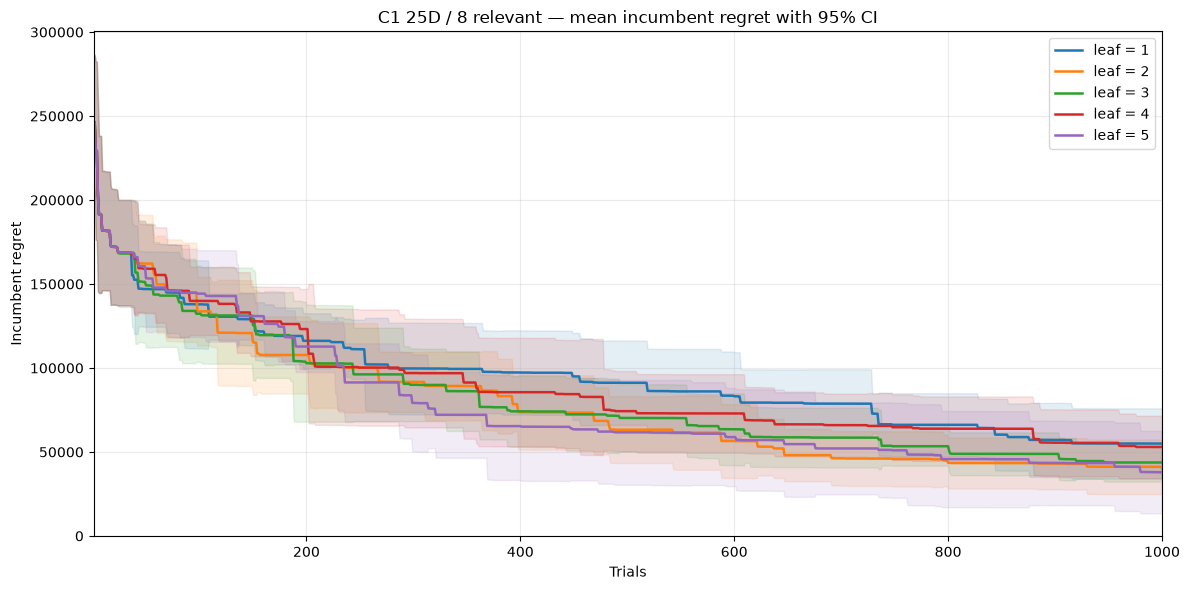

In [5]:
rows = [{"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret} for policy, runs in results.items() for seed, result in runs.items() for iteration, regret in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, data["mean"] - data.ci95, data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="C1 25D / 8 relevant — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS))
ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

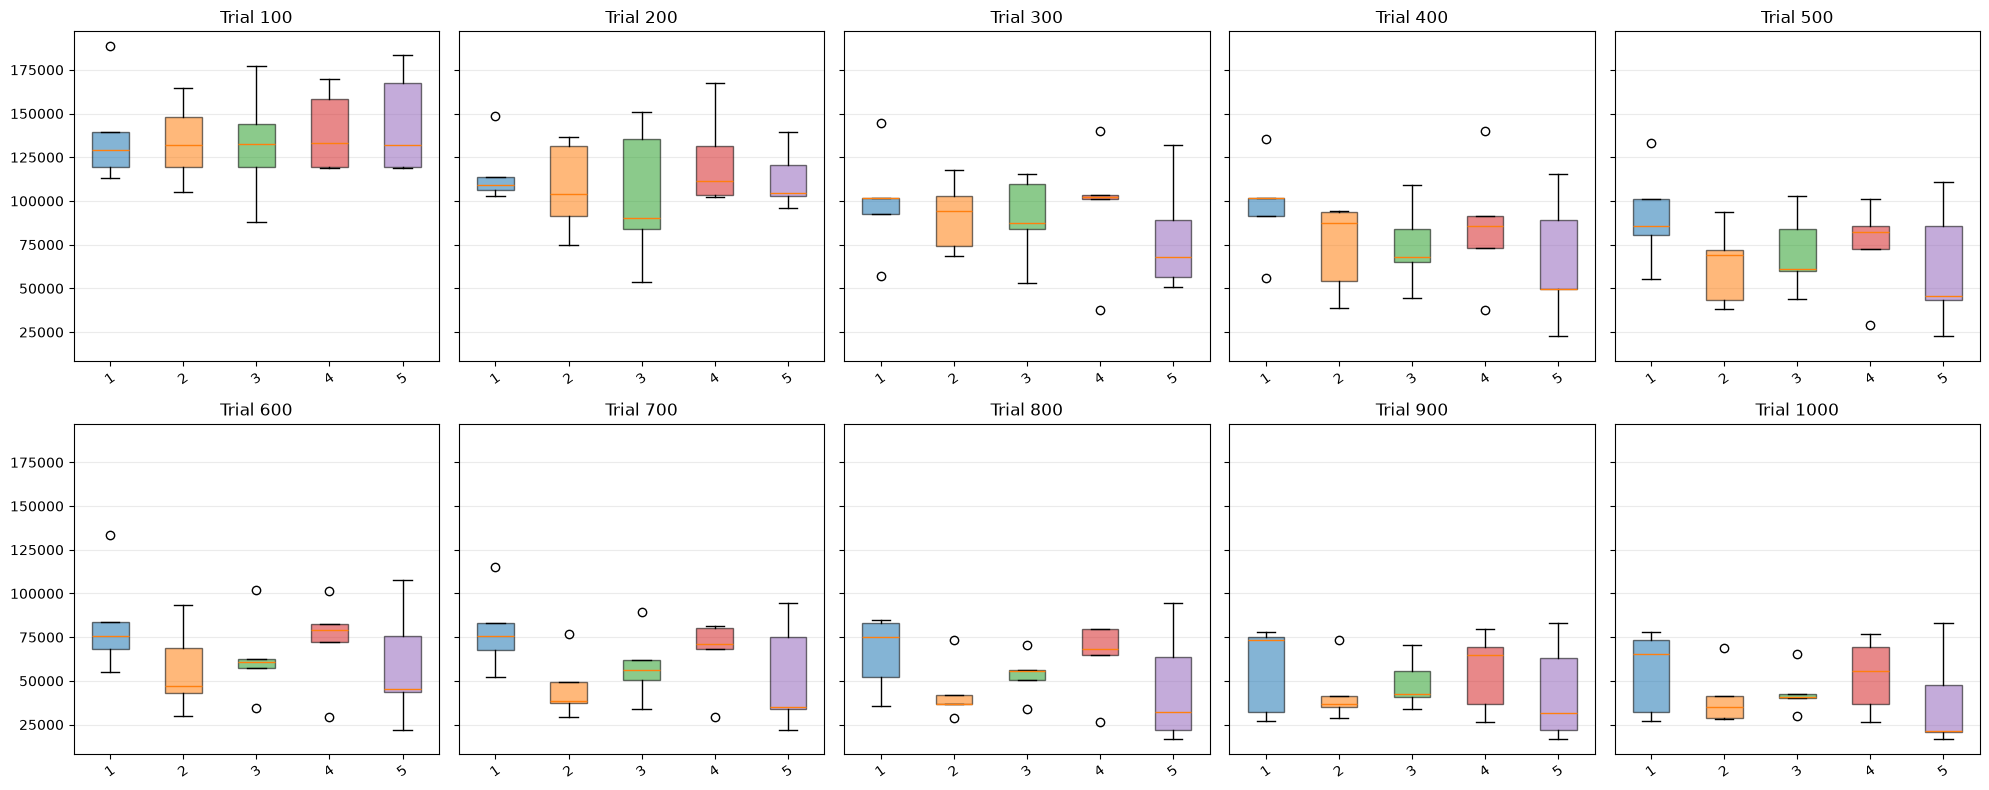

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(leaf) for leaf in LEAF_SIZES])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x", rotation=35); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.show()

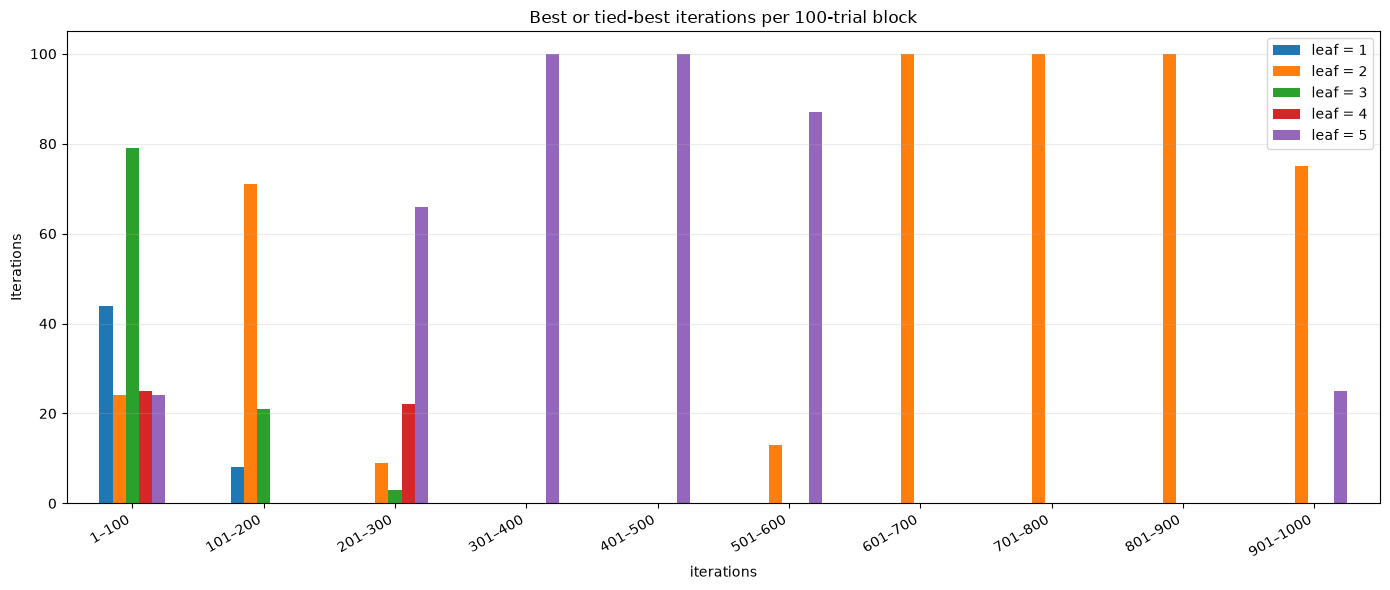

,iterations,superior policy,leaf = 1,leaf = 2,leaf = 3,leaf = 4,leaf = 5
0,1–100,leaf = 3,44,24,79,25,24
1,101–200,leaf = 2,8,71,21,0,0
2,201–300,leaf = 5,0,9,3,22,66
3,301–400,leaf = 5,0,0,0,0,100
4,401–500,leaf = 5,0,0,0,0,100
5,501–600,leaf = 5,0,13,0,0,87
6,601–700,leaf = 2,0,100,0,0,0
7,701–800,leaf = 2,0,100,0,0,0
8,801–900,leaf = 2,0,100,0,0,0
9,901–1000,leaf = 2,0,75,0,0,25


In [7]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum(); maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES}); block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105)); ax.grid(axis="y", alpha=.25); plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(block_superiority)

In [8]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                            \
                  mean           std        median           min   
policy                                                             
leaf = 5  37909.090336  28035.229939  21476.865695  16909.233172   
leaf = 2  40347.647960  16866.802600  34812.526960  28070.288215   
leaf = 3  43729.720908  12961.372165  40724.312171  29937.585864   
leaf = 4  52950.885703  21194.729959  55598.366328  26442.966176   
leaf = 1  55020.040365  23868.606616  65102.864481  26821.318497   

                       mean_incumbent_regret                              \
                   max                  mean           std        median   
policy                                                                     
leaf = 5  83089.885711          77783.143739  26445.254183  61585.982445   
leaf = 2  68988.571135          77878.665842  21514.864641  83076.097764   
leaf = 3  65161.650741          81131.199815  19941.149297  79273.064250   
leaf = 4  76705.668726          89135.647343  25778.458432  91394.721043   
leaf = 1  77681.399677          93812.180565  22275.089569  91907.842591   

                                       
                   min            max  
policy                                 
leaf = 5  57339.754536  118957.789020  
leaf = 2  55744.498733  107364.414018  
leaf = 3  57737.648773  108865.499127  
leaf = 4  49735.779379  120552.177845  
leaf = 1  71179.592656  128203.485116

,policy,seed,final_regret,mean_incumbent_regret
24,leaf = 5,0,20589.308464,61172.190717
4,leaf = 1,0,32033.275046,71179.592656
9,leaf = 2,0,34812.526960,83076.097764
19,leaf = 4,0,36834.420789,85023.516525
14,leaf = 3,0,42567.261494,68322.400180
8,leaf = 2,1,28070.288215,57703.174832
13,leaf = 3,1,29937.585864,57737.648773
23,leaf = 5,1,47480.158640,89860.001974
3,leaf = 1,1,65102.864481,91907.842591
18,leaf = 4,1,69173.006498,91394.721043


In [9]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None): display(checkpoint_table)

mean           std            min  \
iteration policy                                                     
100       fixed_leaf_1  137887.566400  29942.084165  113177.554605   
          fixed_leaf_2  133727.819011  23283.918879  105001.901273   
          fixed_leaf_3  132281.593422  32653.082011   88153.343006   
          fixed_leaf_4  139907.115217  23119.337164  118916.412235   
          fixed_leaf_5  144249.803585  29466.849071  118851.545664   
200       fixed_leaf_1  116190.729342  18685.263383  102963.793400   
          fixed_leaf_2  107710.431485  26199.645127   74748.594191   
          fixed_leaf_3  102836.201398  39698.634930   53596.374073   
          fixed_leaf_4  123178.614998  27223.968874  102459.690842   
          fixed_leaf_5  112751.103534  17304.594282   96100.755306   
300       fixed_leaf_1   99666.863899  31142.818187   57268.726974   
          fixed_leaf_2   91676.211802  20414.555250   68354.304710   
          fixed_leaf_3   89991.273888  24704.347781   53304.047489   
          fixed_leaf_4   96970.470227  36916.108799   37750.610710   
          fixed_leaf_5   79201.388115  32915.883337   50602.160826   
400       fixed_leaf_1   97277.647164  28621.878825   55704.483588   
          fixed_leaf_2   73686.279387  25433.382004   38852.076896   
          fixed_leaf_3   74181.972188  24101.295902   44374.776207   
          fixed_leaf_4   85571.135388  36868.146346   37750.610710   
          fixed_leaf_5   65381.736681  36568.890188   22965.430722   
500       fixed_leaf_1   91179.673519  28660.750187   55397.786953   
          fixed_leaf_2   63248.288928  22654.163304   38391.393778   
          fixed_leaf_3   70249.670032  22983.199641   43914.093088   
          fixed_leaf_4   74297.244471  27223.875501   29294.276554   
          fixed_leaf_5   61672.759010  35589.954243   22965.430722   
600       fixed_leaf_1   83143.982448  29966.196896   54838.959688   
          fixed_leaf_2   56492.958813  25081.038566   29744.386217   
          fixed_leaf_3   63503.509092  24376.939109   34488.590802   
          fixed_leaf_4   72908.676031  26668.292361   29260.877703   
          fixed_leaf_5   58834.006030  33359.037476   21962.733910   
700       fixed_leaf_1   78785.500902  23315.112891   52211.695663   
          fixed_leaf_2   46176.943809  18494.191133   29387.650717   
          fixed_leaf_3   58508.082158  20254.400557   34063.275230   
          fixed_leaf_4   65976.712656  21383.436469   29156.398229   
          fixed_leaf_5   52093.308098  31178.045015   21858.254436   
800       fixed_leaf_1   66157.725703  21478.452988   35734.107207   
          fixed_leaf_2   43501.064329  17353.801274   28702.257919   
          fixed_leaf_3   53407.771005  13238.648644   33998.367965   
          fixed_leaf_4   63808.050342  21917.681485   26443.037109   
          fixed_leaf_5   45748.904599  32669.179446   16909.233172   
900       fixed_leaf_1   57124.762242  25242.317003   27020.561813   
          fixed_leaf_2   43021.053124  17438.738038   28702.257919   
          fixed_leaf_3   48832.589988  14603.468743   33998.367965   
          fixed_leaf_4   55508.378740  22655.712453   26443.037109   
          fixed_leaf_5   43458.845132  28667.861658   16909.233172   
1000      fixed_leaf_1   55020.040365  23868.606616   26821.318497   
          fixed_leaf_2   40347.647960  16866.802600   28070.288215   
          fixed_leaf_3   43729.720908  12961.372165   29937.585864   
          fixed_leaf_4   52950.885703  21194.729959   26442.966176   
          fixed_leaf_5   37909.090336  28035.229939   16909.233172   

                               median            max  
iteration policy                                      
100       fixed_leaf_1  129009.234986  188446.203707  
          fixed_leaf_2  131923.960363  164337.100634  
          fixed_leaf_3  132397.521643  177128.154387  
          fixed_leaf_4  133032.984668  169865.270524  
          fixed_leaf_5  132066.684886  183274.411581  
200    